# 02 - Exploratory Data Analysis (EDA)

## Objetivo

Analizar patrones de fraude y diferencias entre
transacciones fraudulentas y legítimas.

Se evaluarán:

- distribución del target
- montos de transacción
- variables categóricas
- patrones temporales
- missing values
- señales potenciales de fraude

In [1]:
import pandas as pd

# ==========================================
# LOAD DATA
# ==========================================

train = pd.read_parquet(
    "data/processed/train_merged.parquet"
)

print("Shape:")
print(train.shape)

print("\nMemory usage (GB):")
print(
    round(
        train.memory_usage(deep=True).sum()
        / 1024**3,
        2
    )
)

print("\nTarget distribution:")
print(
    train["isFraud"]
    .value_counts(normalize=True)
    * 100
)

Shape:
(590540, 434)

Memory usage (GB):
1.94

Target distribution:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


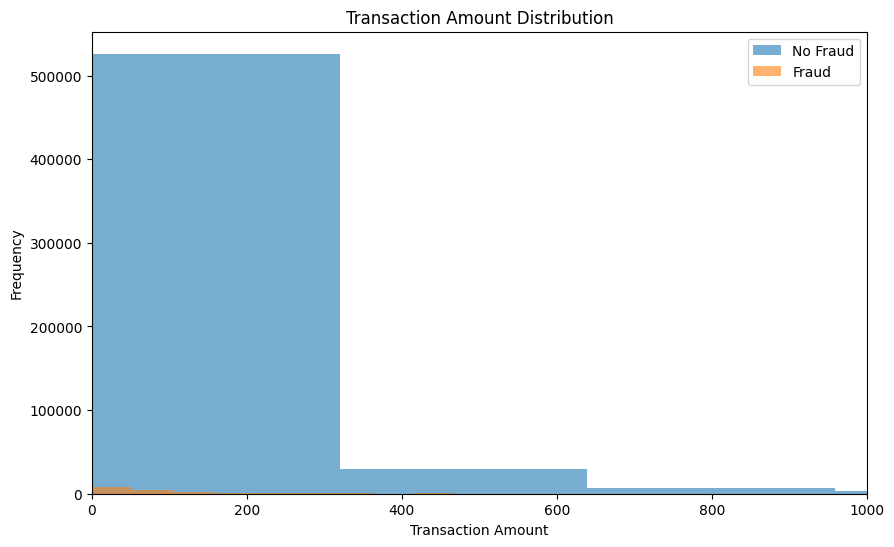

In [2]:
# ==========================================
# TRANSACTION AMOUNT ANALYSIS
# ==========================================

train.groupby("isFraud")["TransactionAmt"].describe()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    train.loc[
        train["isFraud"] == 0,
        "TransactionAmt"
    ],
    bins=100,
    alpha=0.6,
    label="No Fraud"
)

plt.hist(
    train.loc[
        train["isFraud"] == 1,
        "TransactionAmt"
    ],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.xlim(0, 1000)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.show()

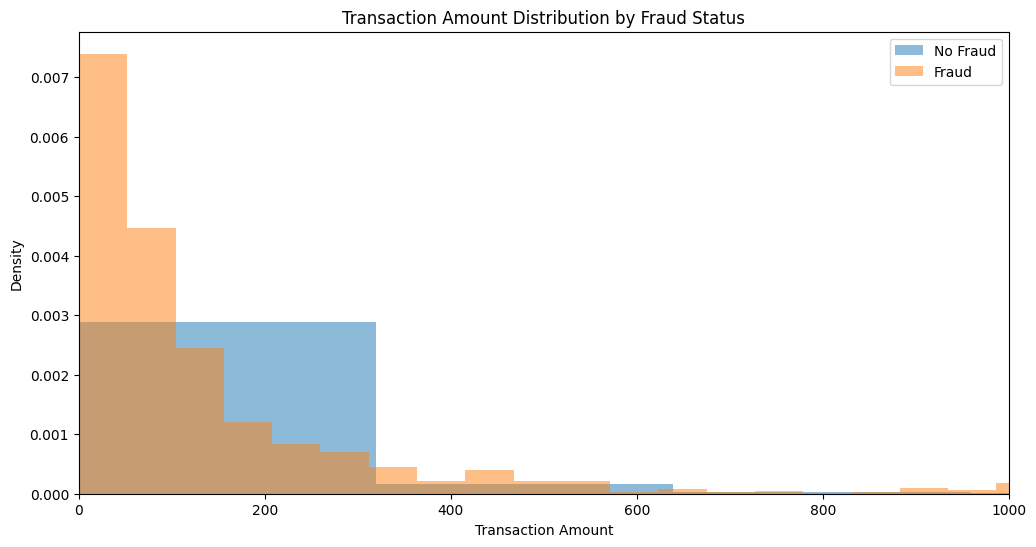

In [3]:
plt.figure(figsize=(12,6))

plt.hist(
    train.loc[
        train["isFraud"] == 0,
        "TransactionAmt"
    ],
    bins=100,
    density=True,
    alpha=0.5,
    label="No Fraud"
)

plt.hist(
    train.loc[
        train["isFraud"] == 1,
        "TransactionAmt"
    ],
    bins=100,
    density=True,
    alpha=0.5,
    label="Fraud"
)

plt.xlim(0, 1000)

plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.title(
    "Transaction Amount Distribution by Fraud Status"
)

plt.legend()

plt.show()

In [4]:
train.groupby(
    "isFraud"
)["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [5]:
# ==========================================
# FRAUD RATE BY PRODUCT
# ==========================================

product_fraud = pd.crosstab(
    train["ProductCD"],
    train["isFraud"],
    normalize="index"
) * 100

display(product_fraud)

isFraud,0,1
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


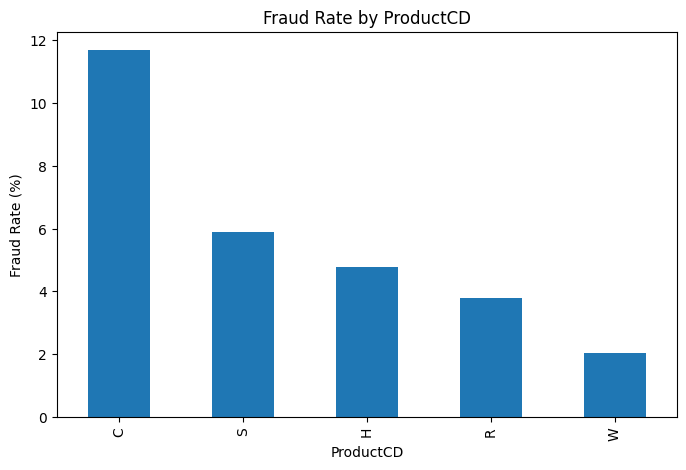

In [6]:
fraud_rate = (
    train.groupby("ProductCD")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8,5))

fraud_rate.plot(kind="bar")

plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by ProductCD")

plt.show()

In [7]:
# ==========================================
# FRAUD RATE BY card4
# ==========================================

card4_fraud = pd.crosstab(
    train["card4"],
    train["isFraud"],
    normalize="index"
) * 100

display(card4_fraud)

isFraud,0,1
card4,,
american express,97.130163,2.869837
discover,92.271839,7.728161
mastercard,96.566905,3.433095
visa,96.524390,3.475610


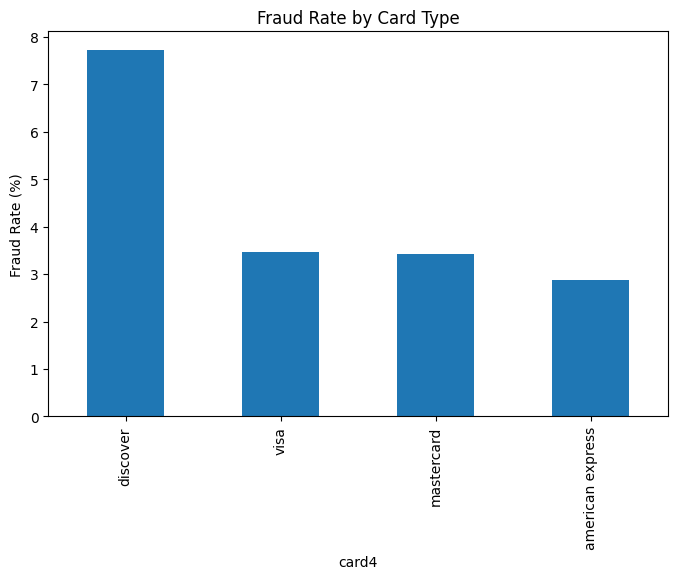

In [8]:
fraud_rate_card4 = (
    train.groupby("card4")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8,5))

fraud_rate_card4.plot(kind="bar")

plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Card Type")

plt.show()

In [9]:
# ==========================================
# CARD4 DISTRIBUTION
# ==========================================

card_counts = (
    train["card4"]
    .value_counts(dropna=False)
)

display(card_counts)

print("\nPercentages:")

display(
    train["card4"]
    .value_counts(
        normalize=True,
        dropna=False
    ) * 100
)

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64


Percentages:


card4
visa                65.155112
mastercard          32.041352
american express     1.410235
discover             1.126257
NaN                  0.267044
Name: proportion, dtype: float64

In [10]:
# ==========================================
# EMAIL DOMAIN FRAUD RATE
# ==========================================

email_stats = (
    train.groupby("P_emaildomain")
    .agg(
        transactions=("isFraud", "count"),
        fraud_rate=("isFraud", "mean")
    )
)

email_stats["fraud_rate"] *= 100

email_stats = email_stats.sort_values(
    by="fraud_rate",
    ascending=False
)

# solo dominios con volumen razonable
email_stats = email_stats[
    email_stats["transactions"] > 1000
]

display(email_stats.head(20))

,transactions,fraud_rate
P_emaildomain,,
outlook.com,5096,9.458399
hotmail.com,45250,5.295028
gmail.com,228355,4.354185
icloud.com,6267,3.143450
comcast.net,7888,3.118661
bellsouth.net,1909,2.776323
live.com,3041,2.762249
anonymous.com,36998,2.321747
yahoo.com,100934,2.275745


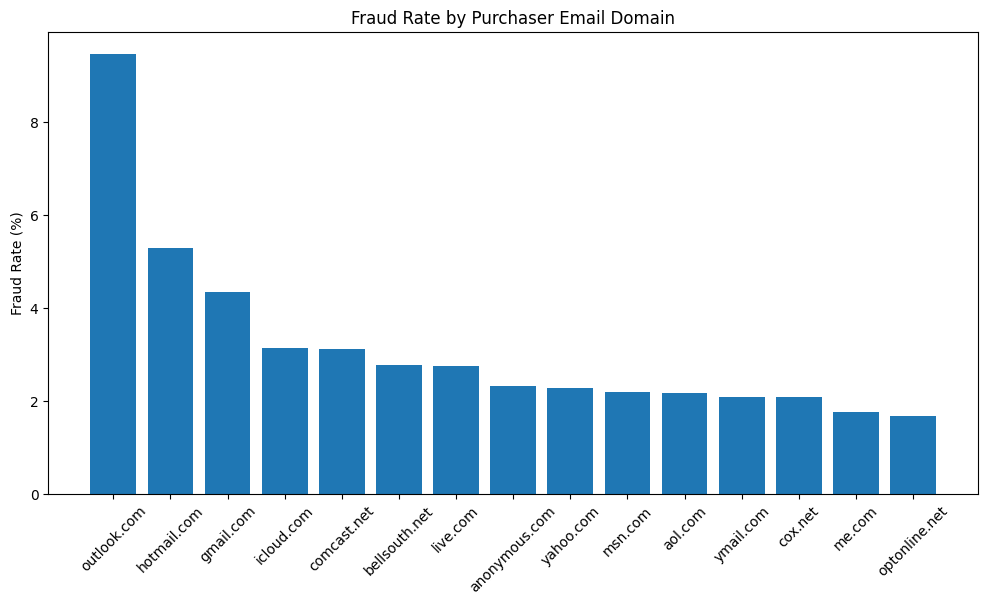

In [11]:
top_email = email_stats.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top_email.index,
    top_email["fraud_rate"]
)

plt.xticks(rotation=45)

plt.ylabel("Fraud Rate (%)")
plt.title(
    "Fraud Rate by Purchaser Email Domain"
)

plt.show()

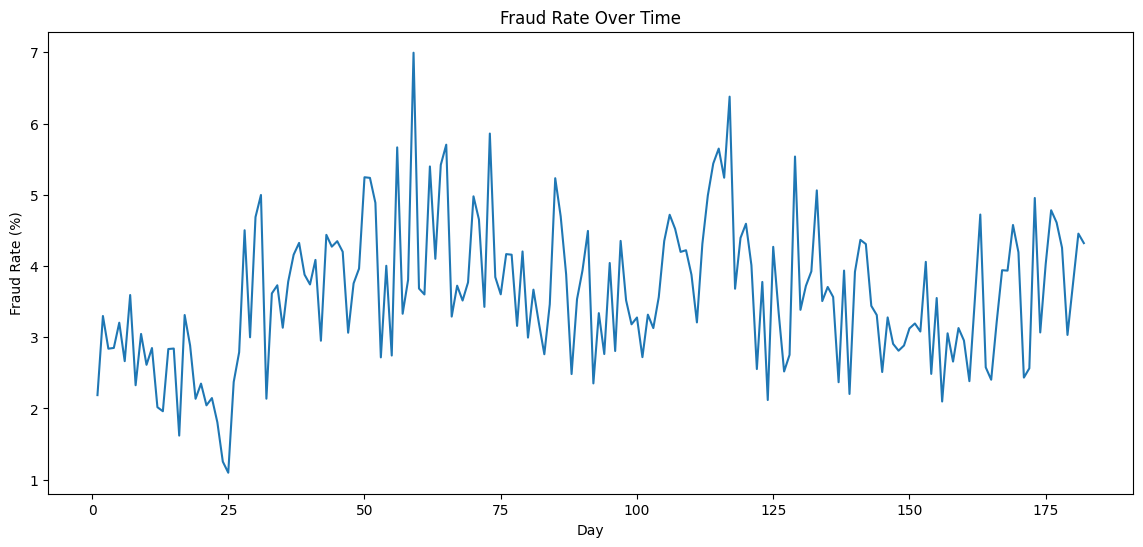

In [12]:
# ==========================================
# TEMPORAL FRAUD PATTERN
# ==========================================

daily_fraud = (
    train.groupby(
        train["TransactionDT"] // 86400
    )["isFraud"]
    .mean()
)

daily_fraud *= 100

plt.figure(figsize=(14,6))

plt.plot(
    daily_fraud.index,
    daily_fraud.values
)

plt.xlabel("Day")
plt.ylabel("Fraud Rate (%)")
plt.title(
    "Fraud Rate Over Time"
)

plt.show()

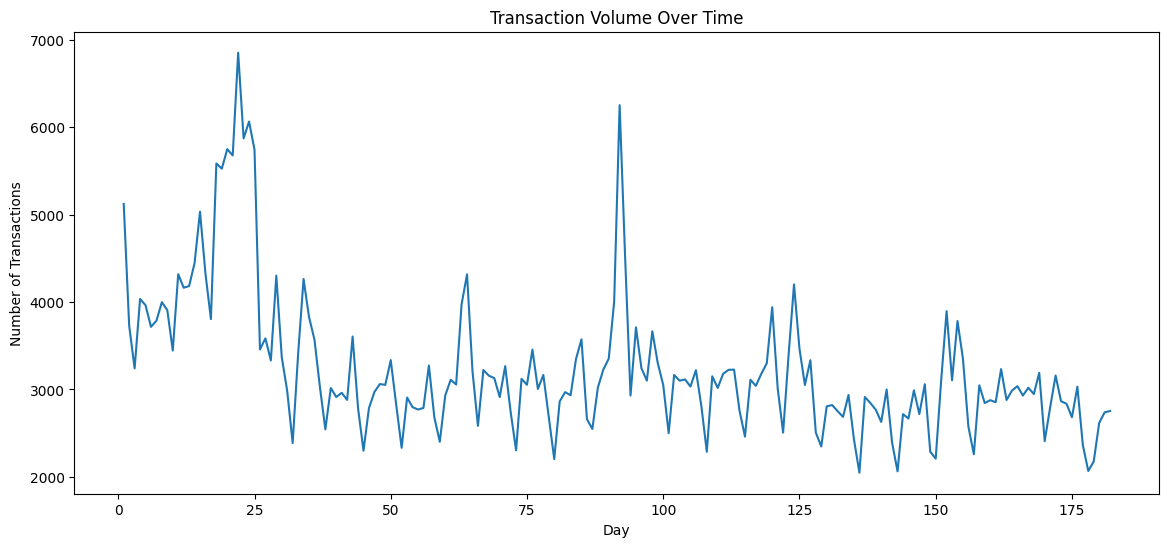

In [13]:
# ==========================================
# TRANSACTION VOLUME OVER TIME
# ==========================================

daily_volume = (
    train.groupby(
        train["TransactionDT"] // 86400
    )
    .size()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_volume.index,
    daily_volume.values
)

plt.xlabel("Day")
plt.ylabel("Number of Transactions")
plt.title(
    "Transaction Volume Over Time"
)

plt.show()

In [14]:
# ==========================================
# FRAUD RATE FOR M VARIABLES
# ==========================================

m_cols = [
    col for col in train.columns
    if col.startswith("M")
]

for col in m_cols:
    
    print("\n" + "="*50)
    print(col)
    print("="*50)

    table = pd.crosstab(
        train[col],
        train["isFraud"],
        normalize="index"
    ) * 100

    display(table)


M1


isFraud,0,1
M1,,
F,100.000000,0.000000
T,98.014495,1.985505



M2


isFraud,0,1
M2,,
F,96.514777,3.485223
T,98.193142,1.806858



M3


...

isFraud,0,1
M7,,
F,98.065514,1.934486
T,97.787301,2.212699



M8


isFraud,0,1
M8,,
F,97.827389,2.172611
T,98.378202,1.621798



M9


isFraud,0,1
M9,,
F,96.999896,3.000104
T,98.221302,1.778698


In [15]:
# ==========================================
# MISSING AS SIGNAL
# ==========================================

cols_to_check = [
    "DeviceType",
    "DeviceInfo",
    "id_30",
    "id_31",
    "dist1",
    "dist2"
]

for col in cols_to_check:
    
    print("\n" + "="*50)
    print(col)
    print("="*50)

    temp = (
        train[col]
        .isna()
        .groupby(train["isFraud"])
        .mean()
        * 100
    )

    print(temp)


DeviceType
isFraud
0    77.258426
1    45.743600
Name: DeviceType, dtype: float64

DeviceInfo
isFraud
0    80.687236
1    58.345836
Name: DeviceInfo, dtype: float64

id_30
isFraud
0    86.993158
1    83.342206
Name: id_30, dtype: float64

id_31
isFraud
0    77.344058
1    45.937182
Name: id_31, dtype: float64

dist1
isFraud
0    59.023789
1    76.987853
Name: dist1, dtype: float64

dist2
isFraud
0    94.052050
1    81.943571
Name: dist2, dtype: float64


In [16]:
# ==========================================
# POTENTIAL LEAKAGE CHECK
# ==========================================

numeric_cols = train.select_dtypes(
    include=["number"]
).columns

corr_target = (
    train[numeric_cols]
    .corr()["isFraud"]
    .abs()
    .sort_values(ascending=False)
)

display(corr_target.head(30))

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
Name: isFraud, dtype: float64